# HMM 市场状态识别与申万一级行业轮动策略

本 Notebook 在既有的**沪深300每月定额定投基准**上，实现三状态 HMM 行业轮动，并在完全一致的回测区间与外部现金流下比较两者。

## 核心口径

- 数据准备区间：2015-01-01 至 2025-12-31；正式回测：2016-01-01 至 2025-12-31。
- 上层状态：沪深300日对数收益率 + 20日年化波动率，`GaussianHMM(n_components=3)`。
- 状态编号：每次重估后按训练样本内平均波动率升序强制映射为 `State 0 / 1 / 2`。
- 信号时点：月末最后交易日收盘后生成；次月第一个交易日收盘调仓。
- Hysteresis：只使用截至信号日的末端后验概率，并对月度概率做单边指数平滑；不使用未来样本。
- 下层配置：各状态候选池内按 20/60/120 日复合动量选前 N 个行业；状态概率用于混合三套目标组合。
- 公平比较：两组账户每月注入相同金额；策略未配置部分留在现金账户并按无风险利率计息。
- 默认 `State 2 = 现金避险`；可在参数中切换为低 Beta 防御行业。

> 这是指数级研究回测。申万行业指数和沪深300价格指数不可直接交易，且价格指数不含分红；正式投资结论应改用可交易 ETF/基金复权数据，并评估跟踪误差与冲击成本。

## 1. 环境准备

首次运行请安装依赖：

```python
%pip install -U akshare hmmlearn
```

AKShare 接口可能受数据源限流或代理影响。Notebook 会优先读取本地缓存，在线成功后也会自动缓存。

In [1]:
from pathlib import Path
from contextlib import contextmanager
from collections import Counter
import json
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.optimize import brentq
from sklearn.preprocessing import StandardScaler

try:
    from hmmlearn.hmm import GaussianHMM
except ImportError as exc:
    raise ImportError(
        "缺少 hmmlearn。请先运行 `%pip install -U hmmlearn` 后重启内核。"
    ) from exc

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC", "Heiti SC",
    "Noto Sans CJK SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 10

## 2. 参数与行业池

参数均集中在此处，避免运行中临时修改。默认交易摩擦与基准相同，沿用原 Notebook 的虚拟指数零费率口径。

In [2]:
CONFIG = {
    "fetch_start": "2015-01-01",
    "backtest_start": "2016-01-01",
    "end_date": "2025-12-31",
    "monthly_contribution": 1_000.0,
    "risk_free_rate": 0,
    "market_symbol": "sh000300",
    "market_code": "000300",
    "vol_window": 20,
    "hmm_components": 3,
    "hmm_covariance_type": "diag",
    "hmm_n_iter": 300,
    "hmm_restarts": 3,
    "hmm_refit_months": 3,
    "min_hmm_observations": 200,
    "min_state_observations": 8,
    "probability_alpha": 0.5,  # 越小，状态概率越平滑
    "momentum_windows": (20, 60, 120),
    "momentum_weights": (0.2, 0.3, 0.5),
    "top_n_risk_on": 4,
    "top_n_neutral": 3,
    "top_n_risk_off": 3,
    "risk_off_mode": "defensive",   # "cash" 或 "defensive"
    "max_industry_weight": 0.35,

    # HMM行业轮动策略和基准策略均不考虑交易费率等摩擦
    "strategy_one_way_cost": 0.0,
    "benchmark_fee_rate": 0.0,

    "cache_dir": "data/hmm_sw_rotation",
    "retry_times": 2,
    "retry_wait_seconds": 1.5,
    "ignore_system_proxy": False,
    "minimum_industry_coverage": 0.90,
    "minimum_available_industries": 20,
    "random_seed": 42,
}

if CONFIG["risk_off_mode"] not in {"cash", "defensive"}:
    raise ValueError("risk_off_mode 必须为 'cash' 或 'defensive'")

if not 0 < CONFIG["probability_alpha"] <= 1:
    raise ValueError("probability_alpha 必须位于 (0, 1]")

if not np.isclose(sum(CONFIG["momentum_weights"]), 1.0):
    raise ValueError("动量权重之和必须为 1")

if CONFIG["strategy_one_way_cost"] != 0.0:
    raise ValueError("本回测不考虑交易摩擦，strategy_one_way_cost 必须为 0")

if CONFIG["benchmark_fee_rate"] != 0.0:
    raise ValueError("本回测不考虑交易摩擦，benchmark_fee_rate 必须为 0")

CONFIG

{'fetch_start': '2015-01-01',
 'backtest_start': '2016-01-01',
 'end_date': '2025-12-31',
 'monthly_contribution': 1000.0,
 'risk_free_rate': 0,
 'market_symbol': 'sh000300',
 'market_code': '000300',
 'vol_window': 20,
 'hmm_components': 3,
 'hmm_covariance_type': 'diag',
 'hmm_n_iter': 300,
 'hmm_restarts': 3,
 'hmm_refit_months': 3,
 'min_hmm_observations': 200,
 'min_state_observations': 8,
 'probability_alpha': 0.5,
 'momentum_windows': (20, 60, 120),
 'momentum_weights': (0.2, 0.3, 0.5),
 'top_n_risk_on': 4,
 'top_n_neutral': 3,
 'top_n_risk_off': 3,
 'risk_off_mode': 'defensive',
 'max_industry_weight': 0.35,
 'strategy_one_way_cost': 0.0,
 'benchmark_fee_rate': 0.0,
 'cache_dir': 'data/hmm_sw_rotation',
 'retry_times': 2,
 'retry_wait_seconds': 1.5,
 'ignore_system_proxy': False,
 'minimum_industry_coverage': 0.9,
 'minimum_available_industries': 20,
 'random_seed': 42}

In [3]:
# 申万 2021 版一级行业代码；保留静态表可避免在线名称接口失败。
SW_FIRST_LEVEL = {
    "801010": "农林牧渔", "801030": "基础化工", "801040": "钢铁",
    "801050": "有色金属", "801080": "电子", "801110": "家用电器",
    "801120": "食品饮料", "801130": "纺织服饰", "801140": "轻工制造",
    "801150": "医药生物", "801160": "公用事业", "801170": "交通运输",
    "801180": "房地产", "801200": "商贸零售", "801210": "社会服务",
    "801230": "综合", "801710": "建筑材料", "801720": "建筑装饰",
    "801730": "电力设备", "801740": "国防军工", "801750": "计算机",
    "801760": "传媒", "801770": "通信", "801780": "银行",
    "801790": "非银金融", "801880": "汽车", "801890": "机械设备",
    "801950": "煤炭", "801960": "石油石化", "801970": "环保",
    "801980": "美容护理",
}

REGIME_POOLS = {
    "State 0 / Risk-On": [
        "电子", "电力设备", "计算机", "医药生物", "非银金融",
        "国防军工", "通信", "汽车", "传媒", "机械设备",
    ],
    "State 1 / Neutral": [
        "基础化工", "有色金属", "银行", "煤炭", "钢铁",
        "建筑材料", "建筑装饰", "家用电器",
    ],
    "State 2 / Risk-Off": [
        "公用事业", "交通运输", "石油石化", "食品饮料",
        "家用电器", "环保",
    ],
}

name_to_code = {name: code_ for code_, name in SW_FIRST_LEVEL.items()}
pool_table = pd.DataFrame(
    [(state, name, name_to_code[name]) for state, names in REGIME_POOLS.items()
     for name in names],
    columns=["状态池", "行业名称", "行业代码"],
)
display(pool_table)

,状态池,行业名称,行业代码
0,State 0 / Risk-On,电子,801080
1,State 0 / Risk-On,电力设备,801730
2,State 0 / Risk-On,计算机,801750
3,State 0 / Risk-On,医药生物,801150
4,State 0 / Risk-On,非银金融,801790
5,State 0 / Risk-On,国防军工,801740
6,State 0 / Risk-On,通信,801770
7,State 0 / Risk-On,汽车,801880
8,State 0 / Risk-On,传媒,801760
9,State 0 / Risk-On,机械设备,801890


## 3. 数据获取：沪深300与申万一级行业

- 沪深300主接口：`ak.stock_zh_index_daily(symbol="sh000300")`，失败时自动尝试腾讯/东方财富接口。
- 行业名称核验：`ak.sw_index_first_info()`。
- 行业日线：逐个调用 `ak.sw_index_daily(symbol="801xxx")`。
- 本地缓存优先，避免每次重复拉取 31 个行业。

In [4]:
@contextmanager
def temporary_proxy_settings(ignore_system_proxy=False):
    keys = [
        "HTTP_PROXY", "HTTPS_PROXY", "ALL_PROXY", "NO_PROXY",
        "http_proxy", "https_proxy", "all_proxy", "no_proxy",
    ]
    old = {key: os.environ.get(key) for key in keys}
    try:
        if ignore_system_proxy:
            for key in keys:
                os.environ.pop(key, None)
            os.environ["NO_PROXY"] = "*"
            os.environ["no_proxy"] = "*"
        yield
    finally:
        for key, value in old.items():
            if value is None:
                os.environ.pop(key, None)
            else:
                os.environ[key] = value


def standardize_close(raw, start=None, end=None):
    aliases = {
        "日期": "date", "date": "date", "Date": "date",
        "收盘": "close", "收盘价": "close", "close": "close", "Close": "close",
    }
    frame = raw.rename(columns={c: aliases.get(c, c) for c in raw.columns}).copy()
    missing = {"date", "close"} - set(frame.columns)
    if missing:
        raise ValueError(f"行情缺少字段：{sorted(missing)}；实际字段={list(raw.columns)}")
    frame = frame[["date", "close"]]
    frame["date"] = pd.to_datetime(frame["date"], errors="coerce")
    frame["close"] = pd.to_numeric(frame["close"], errors="coerce")
    frame = (
        frame.dropna().drop_duplicates("date", keep="last")
        .sort_values("date").set_index("date")
    )
    if start is not None:
        frame = frame.loc[frame.index >= pd.Timestamp(start)]
    if end is not None:
        frame = frame.loc[frame.index <= pd.Timestamp(end)]
    if frame.empty or (frame["close"] <= 0).any():
        raise ValueError("标准化后无有效正价格")
    return frame


def retry(fetcher, label):
    last_error = None
    attempts = max(1, int(CONFIG["retry_times"]))

    for attempt in range(1, attempts + 1):
        try:
            with temporary_proxy_settings(CONFIG["ignore_system_proxy"]):
                result = fetcher()

            if result is None or result.empty:
                raise ValueError("接口返回空数据")

            return result

        except Exception as exc:
            last_error = exc
            print(
                f"  {label} 第 {attempt}/{attempts} 次失败："
                f"{type(exc).__name__}: {exc}"
            )

            if attempt < attempts:
                time.sleep(float(CONFIG["retry_wait_seconds"]))

    # 保留底层真实错误，不再只显示“获取失败”
    raise RuntimeError(
        f"{label} 获取失败；根本原因："
        f"{type(last_error).__name__}: {last_error}"
    ) from last_error


def load_market_close():
    import akshare as ak

    cache = Path(CONFIG["cache_dir"]) / "csi300_daily.csv"
    if cache.exists():
        frame = standardize_close(
            pd.read_csv(cache), CONFIG["fetch_start"], CONFIG["end_date"]
        )
        return frame, f"本地缓存：{cache}"

    start = pd.Timestamp(CONFIG["fetch_start"]).strftime("%Y%m%d")
    end = pd.Timestamp(CONFIG["end_date"]).strftime("%Y%m%d")
    providers = [
        ("AKShare 新浪", lambda: ak.stock_zh_index_daily(symbol=CONFIG["market_symbol"])),
        ("AKShare 腾讯", lambda: ak.stock_zh_index_daily_tx(
            symbol=CONFIG["market_symbol"], start_date=start, end_date=end
        )),
        ("AKShare 东方财富", lambda: ak.index_zh_a_hist(
            symbol=CONFIG["market_code"], period="daily",
            start_date=start, end_date=end
        )),
    ]
    failures = []
    for label, fetcher in providers:
        try:
            raw = retry(fetcher, label)
            frame = standardize_close(raw, CONFIG["fetch_start"], CONFIG["end_date"])
            if frame.index.min() > pd.Timestamp(CONFIG["fetch_start"]) + pd.Timedelta(days=31):
                raise ValueError("起始覆盖不足")
            if frame.index.max() < pd.Timestamp(CONFIG["end_date"]) - pd.Timedelta(days=31):
                raise ValueError("末端覆盖不足")
            cache.parent.mkdir(parents=True, exist_ok=True)
            frame.reset_index().to_csv(cache, index=False, encoding="utf-8-sig")
            return frame, label
        except Exception as exc:
            failures.append(f"{label}: {type(exc).__name__}: {str(exc)[:180]}")
    raise ConnectionError("沪深300全部数据源失败：\n- " + "\n- ".join(failures))


def verify_latest_sw_mapping():
    import akshare as ak
    try:
        latest = retry(lambda: ak.sw_index_first_info(), "申万一级行业映射")
        print(f"在线行业映射返回 {len(latest)} 行；静态研究池固定为 {len(SW_FIRST_LEVEL)} 个行业。")
        display(latest.head())
        return latest
    except Exception as exc:
        print(f"行业名称在线核验失败，继续使用静态映射：{type(exc).__name__}: {exc}")
        return None


def load_one_sw_index(code_, name):
    import akshare as ak

    cache = (
        Path(CONFIG["cache_dir"])
        / "sw_first_level"
        / f"{code_}_{name}.csv"
    )

    # 优先读取有效缓存
    if cache.exists():
        try:
            frame = standardize_close(
                pd.read_csv(cache),
                CONFIG["fetch_start"],
                CONFIG["end_date"],
            )

            if not frame.empty:
                return frame, "cache"

        except Exception as exc:
            print(
                f"  {code_} 缓存无效，重新下载："
                f"{type(exc).__name__}: {exc}"
            )

    # 新版 AKShare 申万指数接口
    raw = retry(
        lambda: ak.index_hist_sw(
            symbol=str(code_),
            period="day",
        ),
        f"{code_} {name}",
    )

    frame = standardize_close(
        raw,
        CONFIG["fetch_start"],
        CONFIG["end_date"],
    )

    # 检查数据覆盖范围
    required_start = pd.Timestamp(CONFIG["fetch_start"])
    required_end = pd.Timestamp(CONFIG["end_date"])

    if frame.index.min() > required_start + pd.Timedelta(days=90):
        raise ValueError(
            f"{code_} {name} 起始覆盖不足："
            f"{frame.index.min().date()}"
        )

    if frame.index.max() < required_end - pd.Timedelta(days=31):
        raise ValueError(
            f"{code_} {name} 末端覆盖不足："
            f"{frame.index.max().date()}"
        )

    cache.parent.mkdir(parents=True, exist_ok=True)
    frame.reset_index().to_csv(
        cache,
        index=False,
        encoding="utf-8-sig",
    )

    return frame, "online"


def load_sw_close_matrix(market_calendar):
    series = {}
    failures = []
    source_counter = Counter()
    for i, (code_, name) in enumerate(SW_FIRST_LEVEL.items(), 1):
        print(f"[{i:02d}/{len(SW_FIRST_LEVEL)}] {code_} {name}")
        try:
            frame, source = load_one_sw_index(code_, name)
            series[code_] = frame["close"].rename(code_)
            source_counter[source] += 1
        except Exception as exc:
            failures.append((code_, name, f"{type(exc).__name__}: {str(exc)[:160]}"))

    if len(series) < CONFIG["minimum_available_industries"]:
        raise RuntimeError(
            f"仅成功获取 {len(series)} 个行业，少于最低要求 "
            f"{CONFIG['minimum_available_industries']}。失败项：{failures}"
        )

    raw_matrix = pd.concat(series.values(), axis=1).sort_index()
    # 仅对交易日对齐并最多前向填充 5 个交易日，不反向填充。
    matrix = raw_matrix.reindex(market_calendar).ffill(limit=5)
    bt_mask = (
        (matrix.index >= pd.Timestamp(CONFIG["backtest_start"]))
        & (matrix.index <= pd.Timestamp(CONFIG["end_date"]))
    )
    coverage = matrix.loc[bt_mask].notna().mean().sort_values(ascending=False)
    keep = coverage[coverage >= CONFIG["minimum_industry_coverage"]].index.tolist()
    if len(keep) < CONFIG["minimum_available_industries"]:
        raise RuntimeError(
            f"覆盖率达标行业仅 {len(keep)} 个。请检查缓存或下调 coverage 参数。"
        )
    return matrix[keep], coverage.rename("覆盖率"), failures, source_counter


market, market_source = load_market_close()
latest_sw_info = verify_latest_sw_mapping()
industry_close, industry_coverage, industry_failures, sw_sources = (
    load_sw_close_matrix(market.index)
)

print(f"沪深300数据源：{market_source}")
print(f"沪深300区间：{market.index.min().date()} 至 {market.index.max().date()}")
print(f"可用行业数：{industry_close.shape[1]}；行业来源：{dict(sw_sources)}")
display(industry_coverage.to_frame())
if industry_failures:
    display(pd.DataFrame(industry_failures, columns=["代码", "名称", "失败原因"]))

在线行业映射返回 31 行；静态研究池固定为 31 个行业。


,行业代码,行业名称,成份个数,静态市盈率,TTM(滚动)市盈率,市净率,静态股息率
0,801010.SI,农林牧渔,104,22.0800,27.7100,2.0600,2.3500
1,801030.SI,基础化工,410,25.7000,24.7600,2.3100,1.6200
2,801040.SI,钢铁,43,16.1200,16.4800,0.9100,2.4600
3,801050.SI,有色金属,140,24.3900,20.3000,3.3400,1.3800
4,801080.SI,电子,494,78.3900,69.7900,7.3200,0.4600


[01/31] 801010 农林牧渔
[02/31] 801030 基础化工
[03/31] 801040 钢铁
[04/31] 801050 有色金属
[05/31] 801080 电子
[06/31] 801110 家用电器
[07/31] 801120 食品饮料
[08/31] 801130 纺织服饰
[09/31] 801140 轻工制造
[10/31] 801150 医药生物
[11/31] 801160 公用事业
[12/31] 801170 交通运输
[13/31] 801180 房地产
[14/31] 801200 商贸零售
[15/31] 801210 社会服务
[16/31] 801230 综合
[17/31] 801710 建筑材料
[18/31] 801720 建筑装饰
[19/31] 801730 电力设备
[20/31] 801740 国防军工
[21/31] 801750 计算机
[22/31] 801760 传媒
[23/31] 801770 通信
[24/31] 801780 银行
[25/31] 801790 非银金融
[26/31] 801880 汽车
[27/31] 801890 机械设备
[28/31] 801950 煤炭
[29/31] 801960 石油石化
[30/31] 801970 环保
[31/31] 801980 美容护理
沪深300数据源：本地缓存：data/hmm_sw_rotation/csi300_daily.csv
沪深300区间：2015-01-05 至 2025-12-31
可用行业数：27；行业来源：{'cache': 28}


,覆盖率
801010,1.0000
801030,1.0000
801890,1.0000
801880,1.0000
801790,1.0000
801780,1.0000
801770,1.0000
801760,1.0000
801750,1.0000
801740,1.0000


,代码,名称,失败原因
0,801960,石油石化,ValueError: 801960 石油石化 起始覆盖不足：2021-12-13
1,801970,环保,ValueError: 801970 环保 起始覆盖不足：2021-12-13
2,801980,美容护理,ValueError: 801980 美容护理 起始覆盖不足：2021-12-13


## 4. 数据质量与特征工程

HMM 特征为：

$$
r_t=\ln(P_t/P_{t-1}),\qquad
\sigma_{20,t}=\operatorname{Std}(r_{t-19:t})\sqrt{252}
$$

特征在每次扩展窗口重估时单独标准化，标准化器只拟合当时可见数据。

In [5]:
market = market.copy()
market["log_return"] = np.log(market["close"]).diff()
market["volatility"] = (
    market["log_return"].rolling(CONFIG["vol_window"]).std(ddof=1) * np.sqrt(252)
)
features = market[["log_return", "volatility"]].dropna()

backtest_market = market.loc[
    (market.index >= pd.Timestamp(CONFIG["backtest_start"]))
    & (market.index <= pd.Timestamp(CONFIG["end_date"]))
].copy()
month_first = (
    backtest_market.reset_index()
    .assign(month=lambda x: x["date"].dt.to_period("M"))
    .groupby("month", as_index=False).first()["date"]
)

calendar = market.index
schedule_rows = []
for execution_date in month_first:
    earlier = calendar[calendar < execution_date]
    if len(earlier) == 0:
        raise ValueError(f"{execution_date.date()} 前无信号日")
    schedule_rows.append(
        {"execution_date": execution_date, "signal_date": earlier[-1]}
    )
schedule = pd.DataFrame(schedule_rows).set_index("execution_date")

quality_report = pd.Series({
    "沪深300交易日数": len(market),
    "正式回测交易日数": len(backtest_market),
    "HMM有效特征日数": len(features),
    "可用申万一级行业数": industry_close.shape[1],
    "月度调仓次数": len(schedule),
    "首个信号日": schedule["signal_date"].min().date(),
    "首个执行日": schedule.index.min().date(),
    "最后执行日": schedule.index.max().date(),
    "行业价格缺失单元格数": int(industry_close.loc[backtest_market.index].isna().sum().sum()),
}, name="检查结果")
display(quality_report.to_frame())
display(schedule.head(12))

,检查结果
沪深300交易日数,2674
正式回测交易日数,2430
HMM有效特征日数,2654
可用申万一级行业数,27
月度调仓次数,120
首个信号日,2015-12-31
首个执行日,2016-01-04
最后执行日,2025-12-01
行业价格缺失单元格数,0


,signal_date
execution_date,
2016-01-04,2015-12-31
2016-02-01,2016-01-29
2016-03-01,2016-02-29
2016-04-01,2016-03-31
2016-05-03,2016-04-29
2016-06-01,2016-05-31
2016-07-01,2016-06-30
2016-08-01,2016-07-29
2016-09-01,2016-08-31


## 5. 扩展窗口 HMM 与状态概率

每三个月重估一次参数，其他月份用最近一次已拟合参数更新过滤概率。`hmmlearn.predict_proba` 返回序列后验概率；对序列**最后一个观测**而言，不存在序列内的未来观测，因此末端后验等于当时可用的过滤后验。

每次拟合后，先根据训练窗状态内平均波动率排序，再映射：

- `State 0`：低波扩张 / Risk-On
- `State 1`：宽幅震荡 / Neutral
- `State 2`：高波危机 / Risk-Off

月度有效概率为：

$$
\tilde p_t=\alpha p_t+(1-\alpha)\tilde p_{t-1}
$$

这是单边平滑，只依赖本月和上月信息。

In [6]:
def fit_best_hmm(train_frame):
    scaler = StandardScaler()
    X = scaler.fit_transform(train_frame[["log_return", "volatility"]])
    candidates = []
    for restart in range(CONFIG["hmm_restarts"]):
        seed = CONFIG["random_seed"] + restart
        model = GaussianHMM(
            n_components=CONFIG["hmm_components"],
            covariance_type=CONFIG["hmm_covariance_type"],
            n_iter=CONFIG["hmm_n_iter"],
            min_covar=1e-4,
            random_state=seed,
        )
        try:
            model.fit(X)
            score = model.score(X)
            states = model.predict(X)
            counts = pd.Series(states).value_counts().reindex(
                range(CONFIG["hmm_components"]), fill_value=0
            )
            occupancy_ok = counts.min() >= CONFIG["min_state_observations"]
            candidates.append((occupancy_ok, score, model, scaler, states, counts))
        except Exception as exc:
            print(f"HMM restart={restart} 失败：{type(exc).__name__}: {exc}")
    if not candidates:
        raise RuntimeError("全部 HMM 初始化均失败")
    # 优先选择状态占用合格者，再按对数似然选择。
    best = sorted(candidates, key=lambda x: (x[0], x[1]), reverse=True)[0]
    occupancy_ok, score, model, scaler, states, counts = best
    if not occupancy_ok:
        print(f"警告：最佳模型存在小样本状态，状态计数={counts.to_dict()}")

    state_vol = (
        train_frame.assign(raw_state=states)
        .groupby("raw_state")["volatility"].mean()
        .reindex(range(CONFIG["hmm_components"]))
    )
    if state_vol.isna().any():
        # 极端情况下用模型中心反标准化后的波动率维度补足。
        raw_means = scaler.inverse_transform(model.means_)
        state_vol = state_vol.fillna(
            pd.Series(raw_means[:, 1], index=range(CONFIG["hmm_components"]))
        )
    ordered_raw_states = state_vol.sort_values().index.tolist()
    semantic_to_raw = {semantic: raw for semantic, raw in enumerate(ordered_raw_states)}
    return {
        "model": model,
        "scaler": scaler,
        "semantic_to_raw": semantic_to_raw,
        "state_vol": state_vol,
        "score": score,
        "counts": counts,
    }


def posterior_asof(fitted, history):
    X = fitted["scaler"].transform(history[["log_return", "volatility"]])
    raw_probability = fitted["model"].predict_proba(X)[-1]
    probability = np.array([
        raw_probability[fitted["semantic_to_raw"][semantic]]
        for semantic in range(CONFIG["hmm_components"])
    ])
    return probability / probability.sum()


def momentum_scores_asof(close_matrix, signal_date):
    history = close_matrix.loc[:signal_date]
    result = pd.Series(index=close_matrix.columns, dtype=float)
    for code_ in close_matrix.columns:
        series = history[code_].dropna()
        if len(series) <= max(CONFIG["momentum_windows"]):
            continue
        score = 0.0
        for window, weight in zip(
            CONFIG["momentum_windows"], CONFIG["momentum_weights"]
        ):
            score += weight * (series.iloc[-1] / series.iloc[-window - 1] - 1)
        result.loc[code_] = score
    return result


def select_equal_weight_portfolio(scores, names, top_n, execution_date):
    pool_codes = [
        name_to_code[name] for name in names
        if name in name_to_code and name_to_code[name] in scores.index
    ]
    valid = scores.reindex(pool_codes).dropna()
    # 执行日无价格的行业不可交易。
    valid = valid[
        industry_close.loc[execution_date, valid.index].notna()
    ]
    selected = valid.nlargest(min(top_n, len(valid))).index.tolist()
    if not selected:
        return {}, []
    weight = 1.0 / len(selected)
    return {code_: weight for code_ in selected}, selected


def build_monthly_signals():
    rows = []
    fitted = None
    previous_effective = None

    for i, (execution_date, row) in enumerate(schedule.iterrows()):
        signal_date = row["signal_date"]
        history = features.loc[:signal_date]
        if len(history) < CONFIG["min_hmm_observations"]:
            raise ValueError(
                f"{signal_date.date()} HMM样本仅 {len(history)}，"
                f"少于 {CONFIG['min_hmm_observations']}"
            )
        refit = fitted is None or i % CONFIG["hmm_refit_months"] == 0
        if refit:
            fitted = fit_best_hmm(history)

        raw_probability = posterior_asof(fitted, history)
        if previous_effective is None:
            effective = raw_probability
        else:
            alpha = CONFIG["probability_alpha"]
            effective = alpha * raw_probability + (1 - alpha) * previous_effective
        effective = effective / effective.sum()
        previous_effective = effective

        scores = momentum_scores_asof(industry_close, signal_date)
        on_weights, on_selected = select_equal_weight_portfolio(
            scores, REGIME_POOLS["State 0 / Risk-On"],
            CONFIG["top_n_risk_on"], execution_date
        )
        neutral_weights, neutral_selected = select_equal_weight_portfolio(
            scores, REGIME_POOLS["State 1 / Neutral"],
            CONFIG["top_n_neutral"], execution_date
        )
        if CONFIG["risk_off_mode"] == "defensive":
            off_weights, off_selected = select_equal_weight_portfolio(
                scores, REGIME_POOLS["State 2 / Risk-Off"],
                CONFIG["top_n_risk_off"], execution_date
            )
        else:
            off_weights, off_selected = {}, []

        target = {}
        for probability, component in zip(
            effective, [on_weights, neutral_weights, off_weights]
        ):
            for code_, weight in component.items():
                target[code_] = target.get(code_, 0.0) + probability * weight

        # 单行业上限造成的剩余权重自动进入现金。
        target = {
            code_: min(weight, CONFIG["max_industry_weight"])
            for code_, weight in target.items() if weight > 1e-12
        }
        target_equity = sum(target.values())
        target_cash = max(0.0, 1.0 - target_equity)
        hard_state = int(np.argmax(effective))

        semantic_vol = {
            semantic: float(fitted["state_vol"].loc[raw])
            for semantic, raw in fitted["semantic_to_raw"].items()
        }
        rows.append({
            "execution_date": execution_date,
            "signal_date": signal_date,
            "hmm_refit": refit,
            "hmm_n_obs": len(history),
            "p0_raw": raw_probability[0],
            "p1_raw": raw_probability[1],
            "p2_raw": raw_probability[2],
            "p0_effective": effective[0],
            "p1_effective": effective[1],
            "p2_effective": effective[2],
            "hard_state": hard_state,
            "state_label": ["Risk-On", "Neutral", "Risk-Off"][hard_state],
            "state0_avg_vol": semantic_vol[0],
            "state1_avg_vol": semantic_vol[1],
            "state2_avg_vol": semantic_vol[2],
            "risk_on_selected": ",".join(SW_FIRST_LEVEL[c] for c in on_selected),
            "neutral_selected": ",".join(SW_FIRST_LEVEL[c] for c in neutral_selected),
            "risk_off_selected": ",".join(SW_FIRST_LEVEL[c] for c in off_selected),
            "target_equity_weight": target_equity,
            "target_cash_weight": target_cash,
            "target_weights": target,
        })
    return pd.DataFrame(rows).set_index("execution_date")


signals = build_monthly_signals()
display(signals.head(12))
print("状态月份数：")
display(signals["state_label"].value_counts().to_frame("月份数"))

,signal_date,hmm_refit,hmm_n_obs,p0_raw,p1_raw,p2_raw,p0_effective,p1_effective,p2_effective,hard_state,state_label,state0_avg_vol,state1_avg_vol,state2_avg_vol,risk_on_selected,neutral_selected,risk_off_selected,target_equity_weight,target_cash_weight,target_weights
execution_date,,,,,,,,,,,,,,,,,,,,
2016-01-04,2015-12-31,True,224,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0,Risk-On,0.2505,0.3827,0.5846,"电子,通信,计算机,电力设备","基础化工,建筑材料,有色金属","家用电器,食品饮料,公用事业",1.0000,0.0000,"{'801080': 0.24999999999984818, '801770': 0.24..."
2016-02-01,2016-01-29,False,244,0.0000,0.0000,1.0000,0.5000,0.0000,0.5000,0,Risk-On,0.2505,0.3827,0.5846,"通信,汽车,电子,医药生物","银行,家用电器,基础化工","食品饮料,家用电器,公用事业",1.0000,0.0000,"{'801770': 0.1249999999999241, '801880': 0.124..."
2016-03-01,2016-02-29,False,260,0.0000,0.9986,0.0013,0.2500,0.4993,0.2507,1,Neutral,0.2505,0.3827,0.5846,"汽车,非银金融,电子,医药生物","银行,有色金属,家用电器","食品饮料,家用电器,公用事业",1.0000,0.0000,"{'801880': 0.06250159977590936, '801790': 0.06..."
2016-04-01,2016-03-31,True,283,1.0000,0.0000,0.0000,0.6250,0.2497,0.1253,0,Risk-On,0.2491,0.3705,0.5558,"非银金融,电子,汽车,计算机","有色金属,家用电器,基础化工","食品饮料,家用电器,公用事业",1.0000,0.0000,"{'801790': 0.15625079987860152, '801080': 0.15..."
2016-05-03,2016-04-29,False,303,1.0000,0.0000,0.0000,0.8125,0.1248,0.0627,0,Risk-On,0.2491,0.3705,0.5558,"汽车,电子,电力设备,非银金融","有色金属,建筑材料,家用电器","食品饮料,家用电器,公用事业",1.0000,0.0000,"{'801880': 0.20312539993930073, '801080': 0.20..."
2016-06-01,2016-05-31,False,324,1.0000,0.0000,0.0000,0.9063,0.0624,0.0313,0,Risk-On,0.2491,0.3705,0.5558,"电子,汽车,非银金融,医药生物","有色金属,家用电器,银行","食品饮料,家用电器,交通运输",1.0000,0.0000,"{'801080': 0.2265626999691919, '801880': 0.226..."
2016-07-01,2016-06-30,True,344,1.0000,0.0000,0.0000,0.9531,0.0312,0.0157,0,Risk-On,0.2236,0.3706,0.5516,"电子,汽车,电力设备,医药生物","有色金属,家用电器,银行","食品饮料,家用电器,公用事业",1.0000,0.0000,"{'801080': 0.23828124224592484, '801880': 0.23..."
2016-08-01,2016-07-29,False,365,1.0000,0.0000,0.0000,0.9766,0.0156,0.0078,0,Risk-On,0.2236,0.3706,0.5516,"汽车,医药生物,电子,国防军工","有色金属,家用电器,基础化工","食品饮料,家用电器,公用事业",1.0000,0.0000,"{'801880': 0.24414053081293297, '801150': 0.24..."
2016-09-01,2016-08-31,False,388,1.0000,0.0000,0.0000,0.9883,0.0078,0.0039,0,Risk-On,0.2236,0.3706,0.5516,"电子,国防军工,医药生物,通信","建筑材料,建筑装饰,基础化工","食品饮料,家用电器,公用事业",1.0000,0.0000,"{'801080': 0.2470701837955113, '801740': 0.247..."


状态月份数：


,月份数
state_label,
Risk-On,55
Neutral,46
Risk-Off,19


## 6. 月度调仓与固定定投回测

策略账户与基准账户每月收到相同外部现金流。策略每个交易日按行业指数收盘点位估值，现金按固定无风险利率计息；每月首个交易日将**整个账户**调至概率混合后的目标权重。

交易成本按行业买卖金额绝对值之和乘以单边费率估算，不对现金仓位调整收费。

In [7]:
def run_strategy_backtest():
    dates = backtest_market.index
    px = industry_close.reindex(dates).ffill(limit=5)
    units = {code_: 0.0 for code_ in px.columns}
    cash = 0.0
    cumulative_contribution = 0.0
    daily_rf = (1 + CONFIG["risk_free_rate"]) ** (1 / 252) - 1
    records, trades = [], []
    previous_value = 0.0
    nav = 1.0

    for dt in dates:
        if previous_value > 0:
            cash *= 1 + daily_rf
        prices_today = px.loc[dt]
        position_values = pd.Series({
            code_: units[code_] * prices_today[code_]
            for code_ in px.columns
        })
        cashflow = 0.0
        fee = 0.0
        turnover = 0.0

        if dt in signals.index:
            cashflow = CONFIG["monthly_contribution"]
            cash += cashflow
            cumulative_contribution += cashflow
            pre_fee_value = cash + position_values.sum()
            target = signals.at[dt, "target_weights"]

            # 迭代估计费用与净资产，收敛后精确令现金为剩余值。
            fee_estimate = 0.0
            for _ in range(8):
                net_value = pre_fee_value - fee_estimate
                desired = pd.Series(0.0, index=px.columns)
                for code_, weight in target.items():
                    desired.loc[code_] = net_value * weight
                turnover = (desired - position_values).abs().sum()
                new_fee = turnover * CONFIG["strategy_one_way_cost"]
                if abs(new_fee - fee_estimate) < 1e-8:
                    fee_estimate = new_fee
                    break
                fee_estimate = new_fee
            fee = fee_estimate
            net_value = pre_fee_value - fee
            desired = pd.Series(0.0, index=px.columns)
            for code_, weight in target.items():
                desired.loc[code_] = net_value * weight
            for code_ in px.columns:
                price = prices_today[code_]
                if desired.loc[code_] > 0 and (pd.isna(price) or price <= 0):
                    raise ValueError(f"{dt.date()} {code_} 无有效执行价格")
                units[code_] = 0.0 if desired.loc[code_] == 0 else desired.loc[code_] / price
            position_values = desired
            cash = net_value - desired.sum()
            trades.append({
                "date": dt,
                "signal_date": signals.at[dt, "signal_date"],
                "state_label": signals.at[dt, "state_label"],
                "contribution": cashflow,
                "pre_fee_value": pre_fee_value,
                "turnover": turnover,
                "fee": fee,
                "target_equity_weight": signals.at[dt, "target_equity_weight"],
                "target_cash_weight": signals.at[dt, "target_cash_weight"],
                "holdings": ",".join(
                    f"{SW_FIRST_LEVEL[c]}:{w:.2%}" for c, w in
                    sorted(target.items(), key=lambda x: x[1], reverse=True)
                ),
            })

        market_value = cash + position_values.sum()
        if previous_value > 0:
            daily_return = (market_value - cashflow) / previous_value - 1
        elif cashflow > 0:
            daily_return = market_value / cashflow - 1
        else:
            daily_return = 0.0
        nav *= 1 + daily_return
        previous_value = market_value
        records.append({
            "date": dt,
            "cashflow": cashflow,
            "cash": cash,
            "equity_value": position_values.sum(),
            "market_value": market_value,
            "cumulative_contribution": cumulative_contribution,
            "profit": market_value - cumulative_contribution,
            "investment_return": (
                market_value / cumulative_contribution - 1
                if cumulative_contribution > 0 else np.nan
            ),
            "daily_return": daily_return,
            "time_weighted_nav": nav,
            "cash_weight": cash / market_value if market_value > 0 else 1.0,
        })

    daily = pd.DataFrame(records).set_index("date")
    trades = pd.DataFrame(trades).set_index("date")
    daily["running_peak"] = daily["time_weighted_nav"].cummax()
    daily["drawdown"] = daily["time_weighted_nav"] / daily["running_peak"] - 1
    return daily, trades


def run_dca_benchmark():
    contribution = CONFIG["monthly_contribution"]
    scheduled = set(schedule.index)
    units = 0.0
    cumulative_contribution = 0.0
    records, trades = [], []
    first_execution_close = None

    for dt, row in backtest_market.iterrows():
        close = float(row["close"])
        cashflow = 0.0
        fee = 0.0
        bought = 0.0
        if dt in scheduled:
            cashflow = contribution
            fee = contribution * CONFIG["benchmark_fee_rate"]
            bought = (contribution - fee) / close
            units += bought
            cumulative_contribution += contribution
            if first_execution_close is None:
                first_execution_close = close
            trades.append({
                "date": dt, "contribution": contribution, "close": close,
                "fee": fee, "units_bought": bought,
            })
        value = units * close
        nav = (
            (1 - CONFIG["benchmark_fee_rate"]) * close / first_execution_close
            if first_execution_close is not None else np.nan
        )
        records.append({
            "date": dt, "cashflow": cashflow, "close": close,
            "market_value": value,
            "cumulative_contribution": cumulative_contribution,
            "profit": value - cumulative_contribution,
            "investment_return": (
                value / cumulative_contribution - 1
                if cumulative_contribution > 0 else np.nan
            ),
            "time_weighted_nav": nav,
            "cash_weight": 0.0,
        })

    daily = pd.DataFrame(records).set_index("date")
    daily = daily.loc[daily["cumulative_contribution"] > 0].copy()
    daily["daily_return"] = daily["time_weighted_nav"].pct_change().fillna(0.0)
    daily["running_peak"] = daily["time_weighted_nav"].cummax()
    daily["drawdown"] = daily["time_weighted_nav"] / daily["running_peak"] - 1
    return daily, pd.DataFrame(trades).set_index("date")


strategy_daily, strategy_trades = run_strategy_backtest()
benchmark_daily, benchmark_trades = run_dca_benchmark()

display(strategy_trades.head())
display(strategy_daily.tail())

,signal_date,state_label,contribution,pre_fee_value,turnover,fee,target_equity_weight,target_cash_weight,holdings
date,,,,,,,,,
2016-01-04,2015-12-31,Risk-On,"1,000.0000","1,000.0000","1,000.0000",0.0000,1.0000,0.0000,"电子:25.00%,通信:25.00%,计算机:25.00%,电力设备:25.00%"
2016-02-01,2016-01-29,Risk-On,"1,000.0000","1,767.4193","1,757.7518",0.0000,1.0000,0.0000,"家用电器:16.67%,食品饮料:16.67%,公用事业:16.67%,通信:12.50%,..."
2016-03-01,2016-02-29,Neutral,"1,000.0000","2,773.6217","1,989.2207",0.0000,1.0000,0.0000,"家用电器:25.00%,银行:16.64%,有色金属:16.64%,食品饮料:8.36%,公..."
2016-04-01,2016-03-31,Risk-On,"1,000.0000","4,080.8405","3,588.9846",0.0000,1.0000,0.0000,"非银金融:15.63%,电子:15.63%,汽车:15.63%,计算机:15.63%,家用电..."
2016-05-03,2016-04-29,Risk-On,"1,000.0000","5,131.9867","3,907.9363",0.0000,1.0000,0.0000,"汽车:20.31%,电子:20.31%,电力设备:20.31%,非银金融:20.31%,家用..."


,cashflow,cash,equity_value,market_value,cumulative_contribution,profit,investment_return,daily_return,time_weighted_nav,cash_weight,running_peak,drawdown
date,,,,,,,,,,,,
2025-12-25,0.0000,0.0000,"193,148.5850","193,148.5850","120,000.0000","73,148.5850",0.6096,0.0014,1.7010,0.0000,1.8974,-0.1035
2025-12-26,0.0000,0.0000,"196,526.1844","196,526.1844","120,000.0000","76,526.1844",0.6377,0.0175,1.7308,0.0000,1.8974,-0.0878
2025-12-29,0.0000,0.0000,"194,796.9766","194,796.9766","120,000.0000","74,796.9766",0.6233,-0.0088,1.7155,0.0000,1.8974,-0.0959
2025-12-30,0.0000,0.0000,"195,696.7531","195,696.7531","120,000.0000","75,696.7531",0.6308,0.0046,1.7235,0.0000,1.8974,-0.0917
2025-12-31,0.0000,0.0000,"196,165.2366","196,165.2366","120,000.0000","76,165.2366",0.6347,0.0024,1.7276,0.0000,1.8974,-0.0895


## 7. 全指标比较

这里同时报告两类收益：

- **投入收益率 / XIRR**：反映每月追加本金后的投资者实际体验。
- **时间加权净值 / Sharpe / 最大回撤**：剔除外部现金流影响，衡量策略本身。

Sharpe 与 Sortino 使用配置中的年化无风险利率；最大回撤基于时间加权净值，而不是累计投入收益率。

In [8]:
def xnpv(rate, cashflows):
    first_date = cashflows[0][0]
    return sum(
        amount / (1 + rate) ** ((date - first_date).days / 365.0)
        for date, amount in cashflows
    )


def xirr(cashflows):
    if not (any(v < 0 for _, v in cashflows) and any(v > 0 for _, v in cashflows)):
        return np.nan
    lower, upper = -0.9999, 1.0
    f_lower, f_upper = xnpv(lower, cashflows), xnpv(upper, cashflows)
    while f_lower * f_upper > 0 and upper < 1_000:
        upper *= 2
        f_upper = xnpv(upper, cashflows)
    if f_lower * f_upper > 0:
        return np.nan
    return brentq(lambda rate: xnpv(rate, cashflows), lower, upper)


def calculate_metrics(daily, trades, name, turnover_column=None):
    returns = daily["daily_return"].replace([np.inf, -np.inf], np.nan).dropna()
    elapsed_years = (daily.index[-1] - daily.index[0]).days / 365.25
    nav_end = daily["time_weighted_nav"].iloc[-1]
    cagr = nav_end ** (1 / elapsed_years) - 1 if elapsed_years > 0 else np.nan
    volatility = returns.std(ddof=1) * np.sqrt(252)
    arithmetic_return = returns.mean() * 252
    sharpe = (
        (arithmetic_return - CONFIG["risk_free_rate"]) / volatility
        if volatility > 0 else np.nan
    )
    daily_rf = (1 + CONFIG["risk_free_rate"]) ** (1 / 252) - 1
    downside = np.minimum(returns - daily_rf, 0)
    downside_deviation = np.sqrt(np.mean(downside ** 2)) * np.sqrt(252)
    sortino = (
        (arithmetic_return - CONFIG["risk_free_rate"]) / downside_deviation
        if downside_deviation > 0 else np.nan
    )
    max_drawdown = daily["drawdown"].min()
    calmar = cagr / abs(max_drawdown) if max_drawdown < 0 else np.nan
    cashflows = [(dt, -float(v)) for dt, v in trades["contribution"].items()]
    cashflows.append((daily.index[-1], float(daily["market_value"].iloc[-1])))
    monthly_nav = daily["time_weighted_nav"].resample("ME").last()
    monthly_returns = monthly_nav.pct_change().dropna()
    total_turnover = (
        trades[turnover_column].sum() if turnover_column else
        trades["contribution"].sum()
    )
    average_value = daily["market_value"].mean()
    return pd.Series({
        "回测开始": daily.index[0].date(),
        "回测结束": daily.index[-1].date(),
        "月度投入次数": len(trades),
        "累计外部投入（元）": daily["cumulative_contribution"].iloc[-1],
        "期末资产（元）": daily["market_value"].iloc[-1],
        "累计盈亏（元）": daily["profit"].iloc[-1],
        "投入累计收益率": daily["investment_return"].iloc[-1],
        "XIRR（资金加权年化）": xirr(cashflows),
        "时间加权累计收益": nav_end - 1,
        "时间加权年化收益": cagr,
        "年化波动率": volatility,
        "Sharpe比率": sharpe,
        "Sortino比率": sortino,
        "最大回撤": max_drawdown,
        "Calmar比率": calmar,
        "月度胜率": (monthly_returns > 0).mean(),
        "平均现金占比": daily["cash_weight"].mean(),
        "总交易金额/平均资产": total_turnover / average_value,
        "总交易成本（元）": trades["fee"].sum(),
    }, name=name)


benchmark_metrics = calculate_metrics(
    benchmark_daily, benchmark_trades, "固定DCA"
)
strategy_metrics = calculate_metrics(
    strategy_daily, strategy_trades, "HMM行业轮动", "turnover"
)
metrics_table = pd.concat([benchmark_metrics, strategy_metrics], axis=1)

percent_rows = [
    "投入累计收益率", "XIRR（资金加权年化）", "时间加权累计收益",
    "时间加权年化收益", "年化波动率", "最大回撤", "月度胜率", "平均现金占比",
]
formatted = metrics_table.copy().astype(object)
for row in percent_rows:
    formatted.loc[row] = metrics_table.loc[row].map(
        lambda x: f"{x:.2%}" if pd.notna(x) else "N/A"
    )
for row in ["累计外部投入（元）", "期末资产（元）", "累计盈亏（元）", "总交易成本（元）"]:
    formatted.loc[row] = metrics_table.loc[row].map(
        lambda x: f"{x:,.2f}" if pd.notna(x) else "N/A"
    )
display(formatted)

,固定DCA,HMM行业轮动
回测开始,2016-01-04,2016-01-04
回测结束,2025-12-31,2025-12-31
月度投入次数,120,120
累计外部投入（元）,"120,000.00","120,000.00"
期末资产（元）,"143,713.05","196,165.24"
累计盈亏（元）,"23,713.05","76,165.24"
投入累计收益率,19.76%,63.47%
XIRR（资金加权年化）,3.54%,9.50%
时间加权累计收益,33.46%,72.76%
时间加权年化收益,2.93%,5.62%


In [9]:
# 相对基准指标：使用时间加权日收益。
aligned = pd.concat(
    [
        benchmark_daily["daily_return"].rename("benchmark"),
        strategy_daily["daily_return"].rename("strategy"),
    ],
    axis=1,
).dropna()
covariance = aligned.cov().loc["strategy", "benchmark"]
benchmark_variance = aligned["benchmark"].var(ddof=1)
beta = covariance / benchmark_variance if benchmark_variance > 0 else np.nan
daily_rf = (1 + CONFIG["risk_free_rate"]) ** (1 / 252) - 1
alpha_daily = (
    (aligned["strategy"].mean() - daily_rf)
    - beta * (aligned["benchmark"].mean() - daily_rf)
)
active = aligned["strategy"] - aligned["benchmark"]
information_ratio = (
    active.mean() / active.std(ddof=1) * np.sqrt(252)
    if active.std(ddof=1) > 0 else np.nan
)
relative_metrics = pd.Series({
    "策略Beta（相对沪深300）": beta,
    "年化Alpha（算术近似）": alpha_daily * 252,
    "与基准日收益相关性": aligned.corr().loc["strategy", "benchmark"],
    "年化跟踪误差": active.std(ddof=1) * np.sqrt(252),
    "信息比率": information_ratio,
    "期末投入收益率差（百分点）": (
        strategy_daily["investment_return"].iloc[-1]
        - benchmark_daily["investment_return"].iloc[-1]
    ) * 100,
    "最大回撤改善（百分点）": (
        strategy_daily["drawdown"].min()
        - benchmark_daily["drawdown"].min()
    ) * 100,
}, name="HMM行业轮动 vs 固定DCA")
display(relative_metrics.to_frame())

,HMM行业轮动 vs 固定DCA
策略Beta（相对沪深300）,1.0138
年化Alpha（算术近似）,0.0327
与基准日收益相关性,0.8675
年化跟踪误差,0.1096
信息比率,0.3041
期末投入收益率差（百分点）,43.7102
最大回撤改善（百分点）,-5.5585


## 8. 可视化

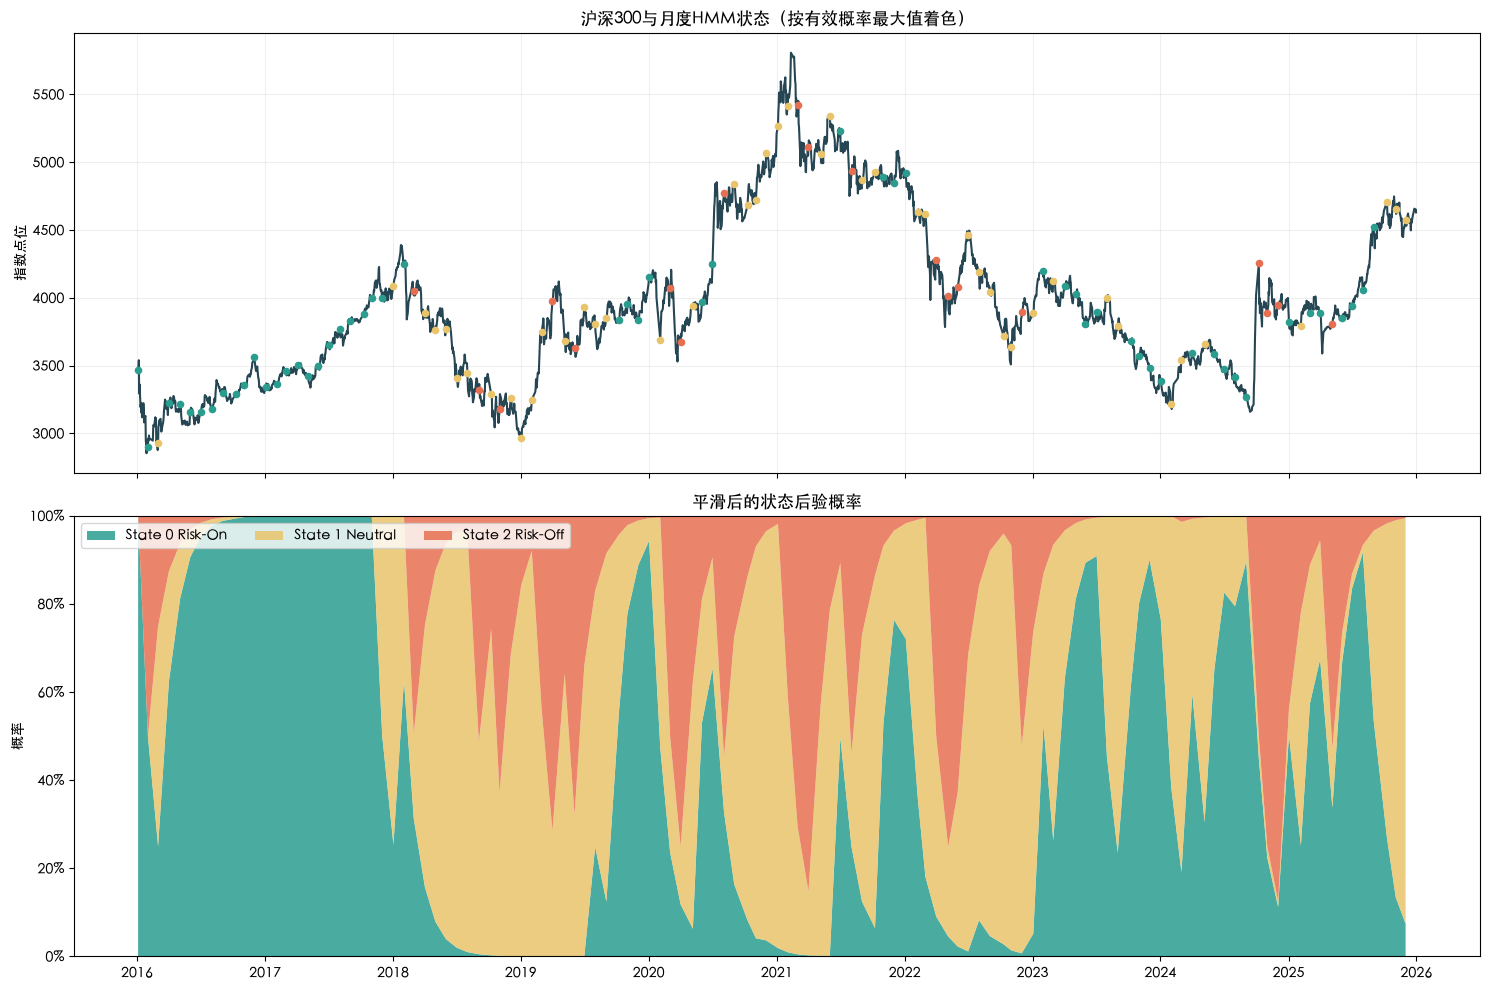

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
axes[0].plot(backtest_market.index, backtest_market["close"], color="#264653", lw=1.5)
state_colors = {0: "#2A9D8F", 1: "#E9C46A", 2: "#E76F51"}
for dt, row in signals.iterrows():
    axes[0].scatter(
        dt, backtest_market.loc[dt, "close"],
        color=state_colors[row["hard_state"]], s=20, zorder=3
    )
axes[0].set_title("沪深300与月度HMM状态（按有效概率最大值着色）")
axes[0].set_ylabel("指数点位")
axes[0].grid(alpha=0.2)

axes[1].stackplot(
    signals.index,
    signals["p0_effective"], signals["p1_effective"], signals["p2_effective"],
    labels=["State 0 Risk-On", "State 1 Neutral", "State 2 Risk-Off"],
    colors=["#2A9D8F", "#E9C46A", "#E76F51"], alpha=0.85,
)
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title("平滑后的状态后验概率")
axes[1].set_ylabel("概率")
axes[1].legend(loc="upper left", ncol=3)
plt.tight_layout()
plt.show()

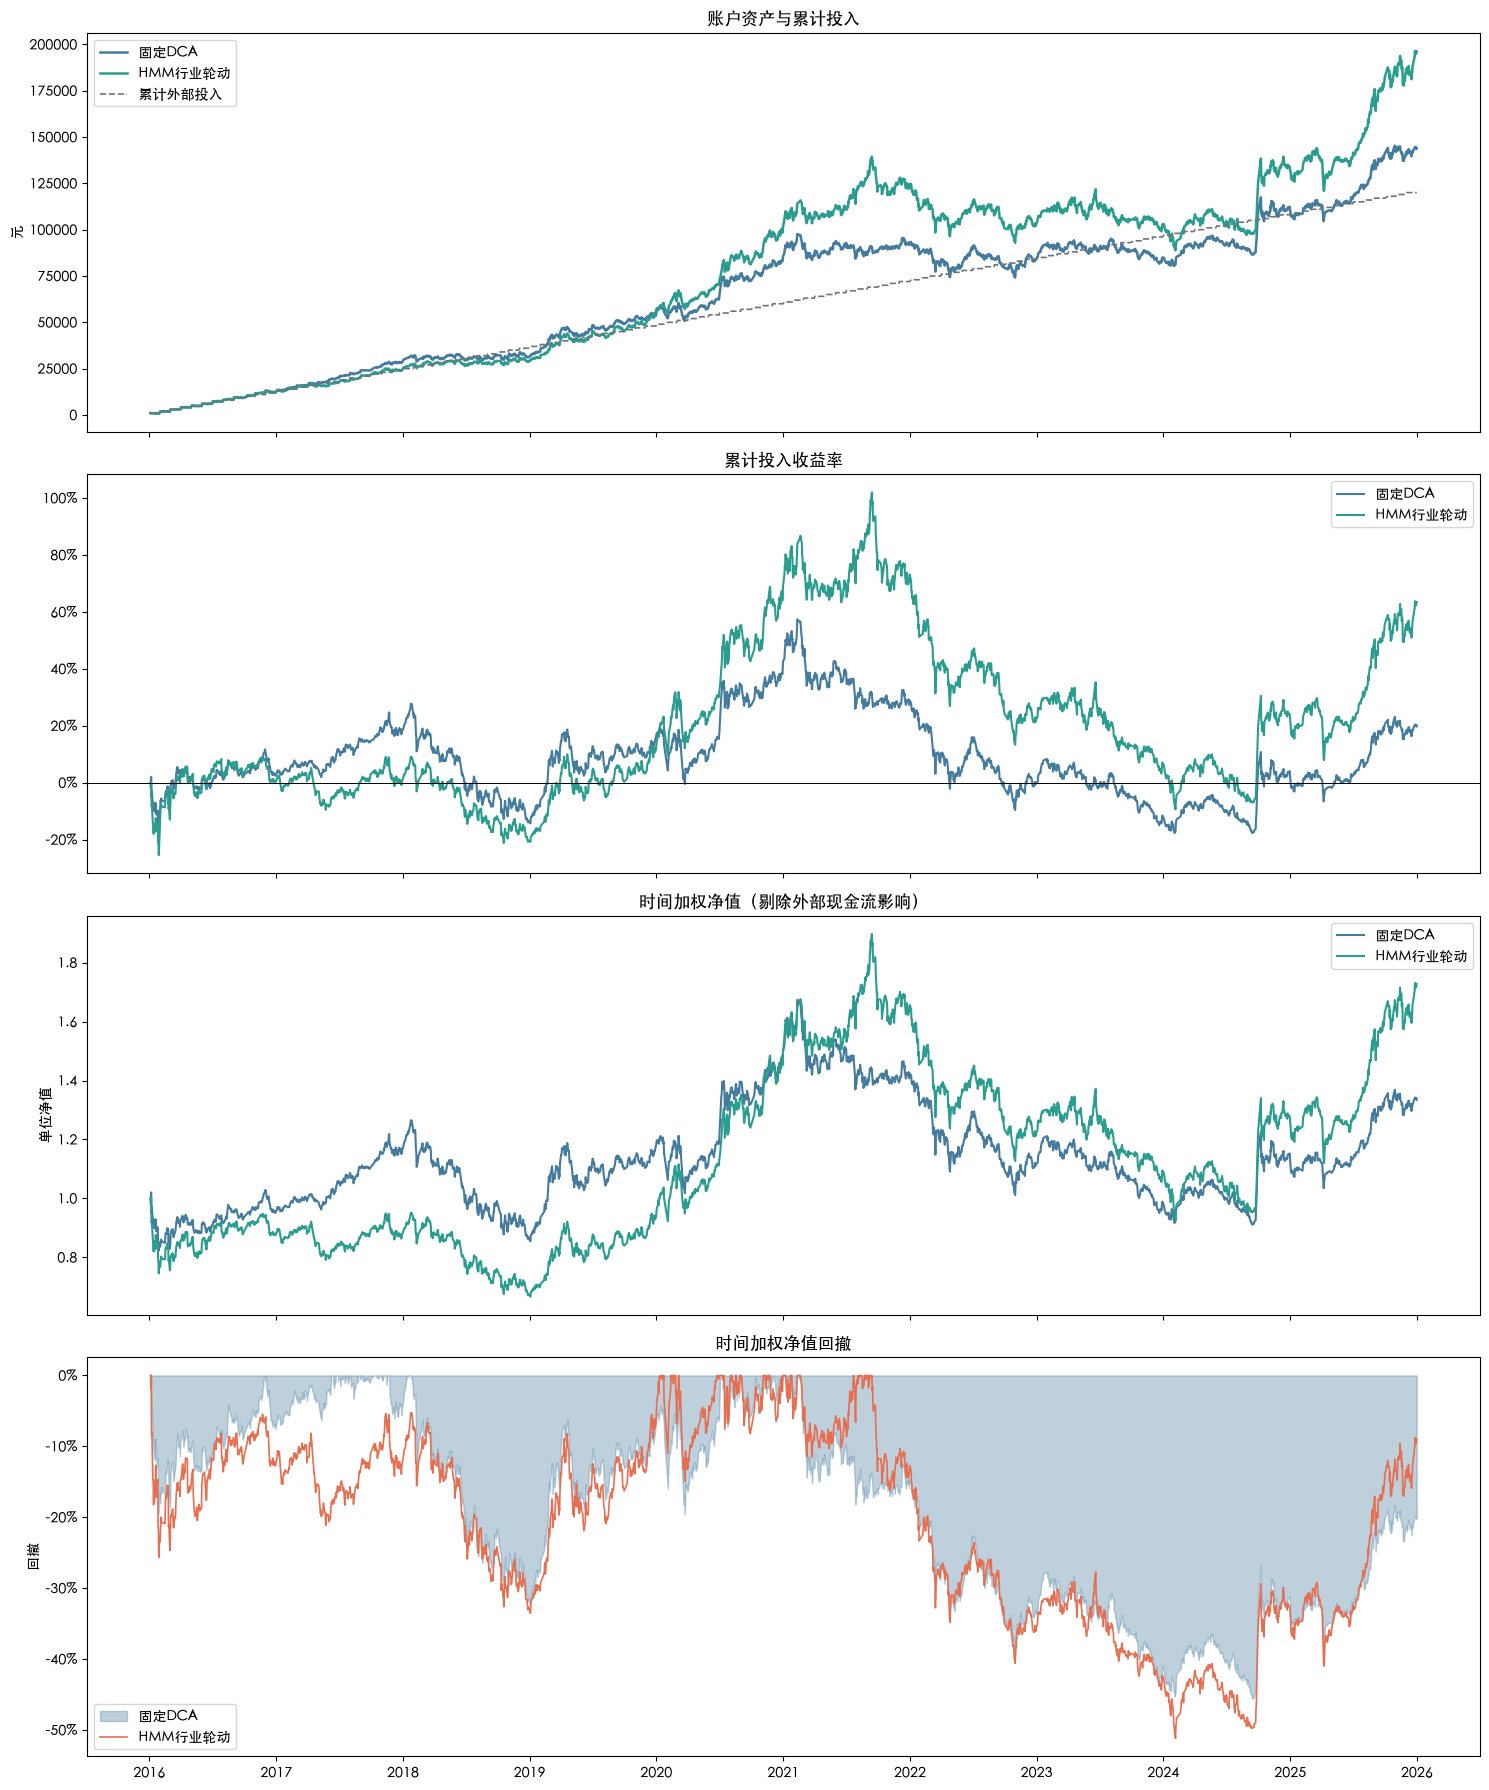

In [11]:
common_index = benchmark_daily.index.intersection(strategy_daily.index)
fig, axes = plt.subplots(4, 1, figsize=(15, 18), sharex=True)

axes[0].plot(
    common_index, benchmark_daily.loc[common_index, "market_value"],
    label="固定DCA", color="#457B9D", lw=1.8
)
axes[0].plot(
    common_index, strategy_daily.loc[common_index, "market_value"],
    label="HMM行业轮动", color="#2A9D8F", lw=1.8
)
axes[0].plot(
    common_index, benchmark_daily.loc[common_index, "cumulative_contribution"],
    label="累计外部投入", color="#6C757D", ls="--", lw=1.2
)
axes[0].set_title("账户资产与累计投入")
axes[0].set_ylabel("元")
axes[0].legend()

axes[1].plot(
    common_index, benchmark_daily.loc[common_index, "investment_return"],
    label="固定DCA", color="#457B9D"
)
axes[1].plot(
    common_index, strategy_daily.loc[common_index, "investment_return"],
    label="HMM行业轮动", color="#2A9D8F"
)
axes[1].axhline(0, color="black", lw=0.7)
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title("累计投入收益率")
axes[1].legend()

axes[2].plot(
    common_index, benchmark_daily.loc[common_index, "time_weighted_nav"],
    label="固定DCA", color="#457B9D"
)
axes[2].plot(
    common_index, strategy_daily.loc[common_index, "time_weighted_nav"],
    label="HMM行业轮动", color="#2A9D8F"
)
axes[2].set_title("时间加权净值（剔除外部现金流影响）")
axes[2].set_ylabel("单位净值")
axes[2].legend()

axes[3].fill_between(
    common_index, benchmark_daily.loc[common_index, "drawdown"], 0,
    label="固定DCA", color="#457B9D", alpha=0.35
)
axes[3].plot(
    common_index, strategy_daily.loc[common_index, "drawdown"],
    label="HMM行业轮动", color="#E76F51", lw=1.2
)
axes[3].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[3].set_title("时间加权净值回撤")
axes[3].set_ylabel("回撤")
axes[3].legend()

plt.tight_layout()
plt.show()

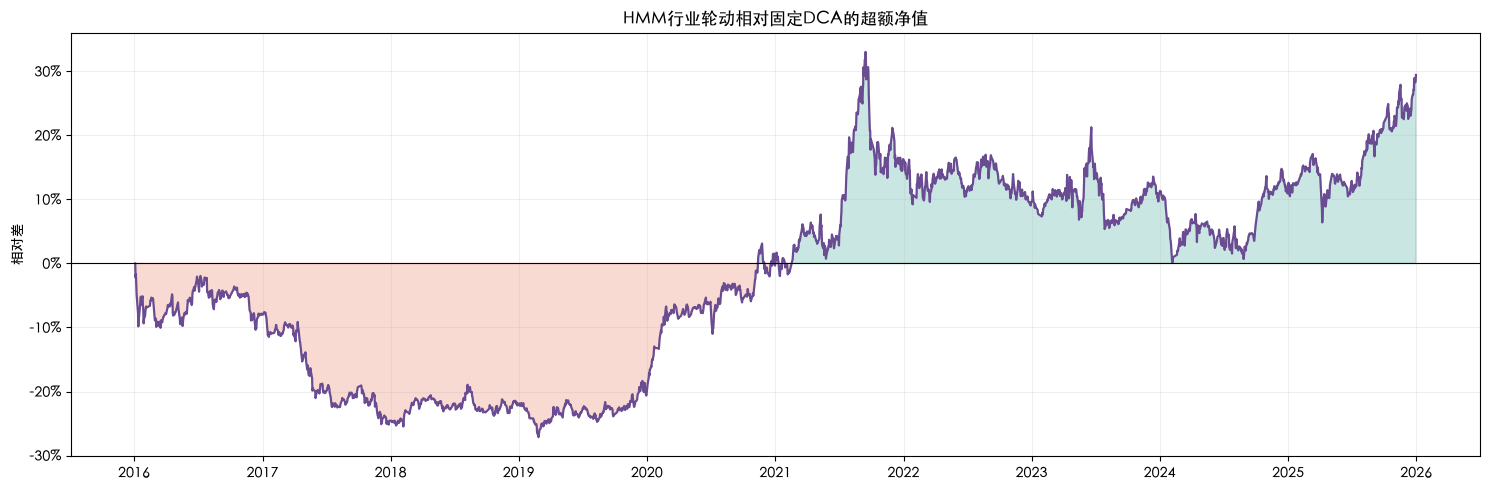

In [12]:
excess_nav = (
    strategy_daily.loc[common_index, "time_weighted_nav"]
    / benchmark_daily.loc[common_index, "time_weighted_nav"] - 1
)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(excess_nav.index, excess_nav, color="#6A4C93", lw=1.6)
ax.fill_between(
    excess_nav.index, excess_nav, 0,
    where=excess_nav >= 0, color="#2A9D8F", alpha=0.25
)
ax.fill_between(
    excess_nav.index, excess_nav, 0,
    where=excess_nav < 0, color="#E76F51", alpha=0.25
)
ax.axhline(0, color="black", lw=0.8)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("HMM行业轮动相对固定DCA的超额净值")
ax.set_ylabel("相对差")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

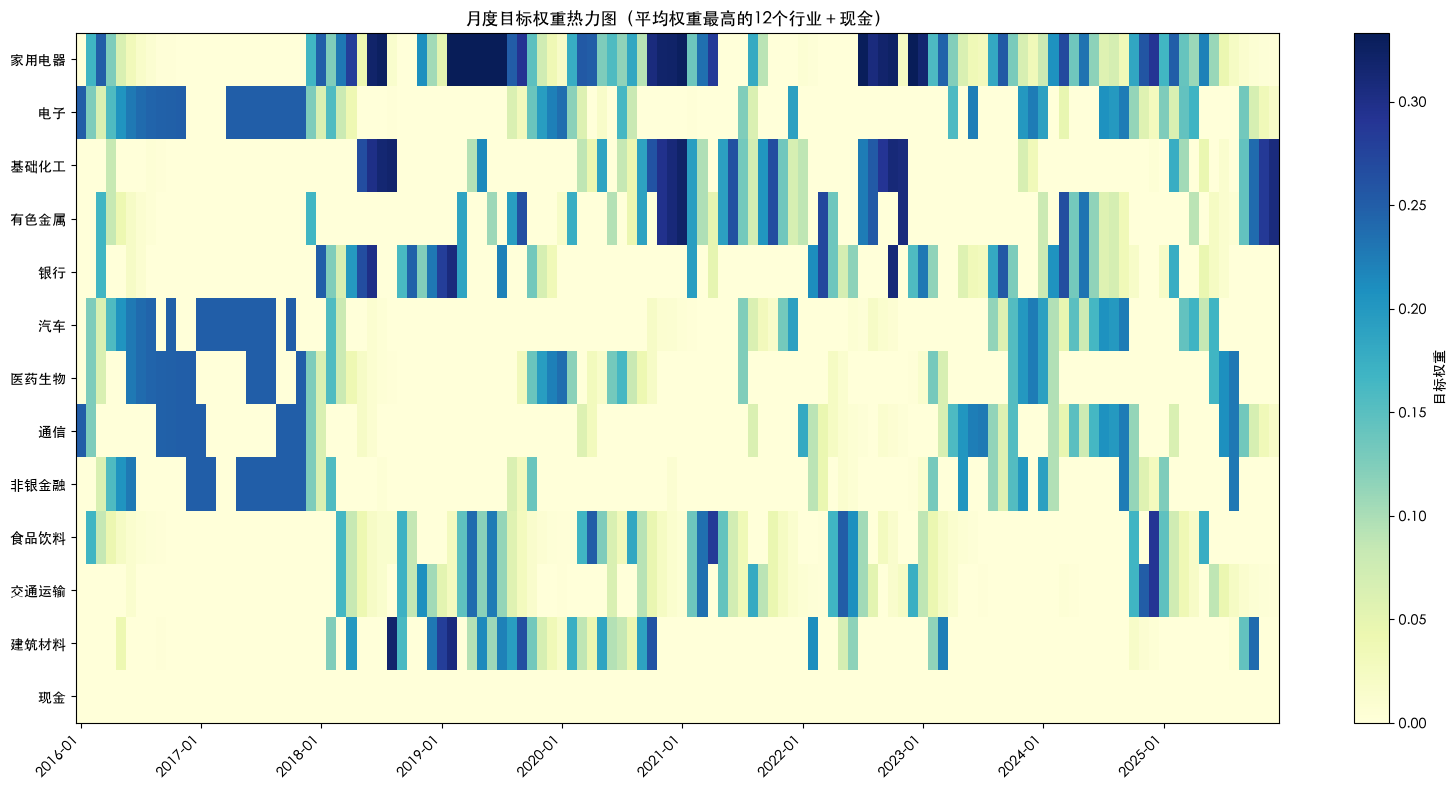

In [13]:
allocation = pd.DataFrame(
    signals["target_weights"].apply(
        lambda d: {SW_FIRST_LEVEL.get(k, k): v for k, v in d.items()}
    ).tolist(),
    index=signals.index,
).fillna(0.0)
allocation["现金"] = signals["target_cash_weight"]
top_columns = (
    allocation.drop(columns="现金").mean().nlargest(12).index.tolist() + ["现金"]
)

fig, ax = plt.subplots(figsize=(16, 8))
image = ax.imshow(
    allocation[top_columns].T.values,
    aspect="auto", interpolation="nearest", cmap="YlGnBu", vmin=0,
)
ax.set_yticks(range(len(top_columns)))
ax.set_yticklabels(top_columns)
tick_positions = np.arange(0, len(allocation), 12)
ax.set_xticks(tick_positions)
ax.set_xticklabels(
    [allocation.index[i].strftime("%Y-%m") for i in tick_positions],
    rotation=45, ha="right",
)
ax.set_title("月度目标权重热力图（平均权重最高的12个行业＋现金）")
fig.colorbar(image, ax=ax, label="目标权重")
plt.tight_layout()
plt.show()

## 9. 年度、状态与行业归因

In [14]:
def annual_summary(daily, name):
    rows = []
    for year, group in daily.groupby(daily.index.year):
        rows.append({
            "年份": year,
            "策略": name,
            "当年外部投入": group["cashflow"].sum(),
            "年末资产": group["market_value"].iloc[-1],
            "年末投入收益率": group["investment_return"].iloc[-1],
            "当年时间加权收益": (1 + group["daily_return"]).prod() - 1,
            "当年最大回撤": (
                (1 + group["daily_return"]).cumprod()
                / (1 + group["daily_return"]).cumprod().cummax() - 1
            ).min(),
        })
    return pd.DataFrame(rows)


annual = pd.concat([
    annual_summary(benchmark_daily, "固定DCA"),
    annual_summary(strategy_daily, "HMM行业轮动"),
], ignore_index=True)
display(annual.pivot(index="年份", columns="策略", values=[
    "当年时间加权收益", "当年最大回撤", "年末投入收益率"
]))

state_summary = signals.groupby("state_label").agg(
    月份数=("state_label", "size"),
    平均股票仓位=("target_equity_weight", "mean"),
    平均现金仓位=("target_cash_weight", "mean"),
    平均RiskOn概率=("p0_effective", "mean"),
    平均Neutral概率=("p1_effective", "mean"),
    平均RiskOff概率=("p2_effective", "mean"),
)
display(state_summary)

selection_counter = Counter()
for target in signals["target_weights"]:
    for code_, weight in target.items():
        if weight > 0:
            selection_counter[SW_FIRST_LEVEL.get(code_, code_)] += 1
selection_frequency = pd.Series(selection_counter, name="入选月份数").sort_values(ascending=False)
display(selection_frequency.to_frame())

当年时间加权收益          当年最大回撤         年末投入收益率        
策略    HMM行业轮动   固定DCA HMM行业轮动   固定DCA HMM行业轮动   固定DCA
年份                                                   
2016  -0.1221 -0.0458 -0.2567 -0.1938  0.0046  0.0285
2017  -0.0014  0.2178 -0.1414 -0.0607  0.0066  0.1816
2018  -0.2297 -0.2531 -0.2933 -0.3188 -0.2035 -0.1335
2019   0.3922  0.3607 -0.1492 -0.1349  0.1207  0.1625
2020   0.5925  0.2721 -0.1494 -0.1608  0.6918  0.4271
2021   0.1062 -0.0520 -0.1617 -0.1819  0.7315  0.2889
2022  -0.2625 -0.2163 -0.3137 -0.2865  0.2231 -0.0018
2023  -0.1034 -0.1138 -0.2302 -0.2151  0.0710 -0.1150
2024   0.1535  0.1468 -0.1536 -0.1441  0.2259  0.0242
2025   0.3676  0.1766 -0.1665 -0.1049  0.6347  0.1976

,月份数,平均股票仓位,平均现金仓位,平均RiskOn概率,平均Neutral概率,平均RiskOff概率
state_label,,,,,,
Neutral,46,1.0000,0.0000,0.1216,0.7350,0.1434
Risk-Off,19,1.0000,0.0000,0.1338,0.2354,0.6308
Risk-On,55,1.0000,0.0000,0.8010,0.1509,0.0481


,入选月份数
家用电器,107
食品饮料,92
交通运输,87
公用事业,71
电子,62
汽车,60
通信,58
银行,57
医药生物,56
有色金属,56


## 10. 无未来函数与会计恒等审计

以下断言只要有一项失败，结果就不应被用于结论。

In [15]:
# 时点审计
assert (signals["signal_date"] < signals.index).all(), "信号日必须早于执行日"
expected_first = (
    backtest_market.reset_index()
    .assign(month=lambda x: x["date"].dt.to_period("M"))
    .groupby("month").first()["date"]
)
assert signals.index.equals(pd.DatetimeIndex(expected_first.values)), "调仓日并非每月首个交易日"

# HMM状态语义排序审计
assert (signals["state0_avg_vol"] <= signals["state1_avg_vol"] + 1e-12).all()
assert (signals["state1_avg_vol"] <= signals["state2_avg_vol"] + 1e-12).all()
assert np.allclose(
    signals[["p0_effective", "p1_effective", "p2_effective"]].sum(axis=1), 1.0
), "状态概率之和不为1"

# 目标权重与现金审计
total_target = signals["target_equity_weight"] + signals["target_cash_weight"]
assert np.allclose(total_target, 1.0), "目标股票+现金权重不为1"
assert (signals["target_cash_weight"] >= -1e-12).all(), "出现负现金目标"
assert all(
    max(target.values(), default=0) <= CONFIG["max_industry_weight"] + 1e-12
    for target in signals["target_weights"]
), "单行业权重超限"

# 现金流和账户核算审计
expected_contribution = len(schedule) * CONFIG["monthly_contribution"]
assert np.isclose(
    strategy_daily["cumulative_contribution"].iloc[-1], expected_contribution
)
assert np.isclose(
    benchmark_daily["cumulative_contribution"].iloc[-1], expected_contribution
)
assert np.isclose(
    strategy_daily["cumulative_contribution"].iloc[-1],
    benchmark_daily["cumulative_contribution"].iloc[-1],
), "两策略累计外部投入不一致"
assert (strategy_daily["cash"] >= -1e-6).all(), "策略现金透支"
assert np.allclose(
    strategy_daily["market_value"],
    strategy_daily["cash"] + strategy_daily["equity_value"],
), "策略资产恒等式失败"
assert strategy_daily["drawdown"].between(-1, 1e-12).all()
assert benchmark_daily["drawdown"].between(-1, 1e-12).all()
assert not strategy_daily[
    ["market_value", "time_weighted_nav", "daily_return"]
].isna().any().any()

print("全部审计通过：无未来执行、状态排序、概率/权重、现金流及账户核算均一致。")

全部审计通过：无未来执行、状态排序、概率/权重、现金流及账户核算均一致。


## 11. 导出结果

`target_weights` 会转为 JSON 字符串，便于 CSV 读取。

In [16]:
output_dir = Path("hmm_sw_rotation_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

signal_export = signals.copy()
signal_export["target_weights"] = signal_export["target_weights"].apply(
    lambda d: json.dumps(
        {f"{code_}_{SW_FIRST_LEVEL.get(code_, code_)}": weight
         for code_, weight in d.items()},
        ensure_ascii=False,
    )
)
signal_export.to_csv(output_dir / "monthly_signals.csv", encoding="utf-8-sig")
strategy_daily.to_csv(output_dir / "strategy_daily.csv", encoding="utf-8-sig")
strategy_trades.to_csv(output_dir / "strategy_trades.csv", encoding="utf-8-sig")
benchmark_daily.to_csv(output_dir / "benchmark_dca_daily.csv", encoding="utf-8-sig")
benchmark_trades.to_csv(output_dir / "benchmark_dca_trades.csv", encoding="utf-8-sig")
metrics_table.to_csv(output_dir / "performance_metrics.csv", encoding="utf-8-sig")
relative_metrics.to_csv(output_dir / "relative_metrics.csv", encoding="utf-8-sig")
annual.to_csv(output_dir / "annual_summary.csv", index=False, encoding="utf-8-sig")
industry_coverage.to_csv(output_dir / "industry_coverage.csv", encoding="utf-8-sig")

print(f"结果已导出至：{output_dir.resolve()}")

结果已导出至：/Users/chenlang/Main/quant-learning-journey/beat DCA/hmm_sw_rotation_outputs


## 12. 结果解释与研究限制

建议按以下顺序解读：

1. 先确认审计全部通过、两组外部现金流相同。
2. 用 XIRR 与投入累计收益率回答“投资者最终赚了多少”。
3. 用时间加权年化收益、Sharpe、Sortino、最大回撤和 Calmar 回答“策略自身质量如何”。
4. 用相对净值、信息比率及分年度结果判断超额收益是否稳定，而非只看期末差值。
5. 查看状态概率和权重热力图，确认收益或回撤改善来自可解释的仓位变化。

### 必须披露的限制

- 当前 HMM 初始训练仅约一年，三状态参数可能不稳定；应补做 2/3/5 年初始窗敏感性测试。
- `GaussianHMM` 是无监督模型，状态只按波动率排序；“扩张/危机”是研究解释而非模型天然标签。
- 当前行业池使用今天可得的申万一级分类并回溯历史，可能存在分类调整与幸存者偏差。
- 动量候选池是预先给定的风格假设，须与“全行业统一排名”做对照，避免人为选池贡献被误认为 HMM Alpha。
- 默认无风险利率固定 2%；可替换为 Shibor 3M 的逐日/逐月历史序列。
- 指数价格不含分红，不能代表可交易产品的总回报；实际策略还需考虑 ETF 可得性、税费、冲击成本和容量。

### 推荐稳健性实验

- `risk_off_mode = cash` vs `defensive`
- HMM 2/3/4 状态
- 20日 vs 60日波动率
- 概率平滑参数 0.2 / 0.35 / 0.5 / 1.0
- 月度 vs 季度 HMM 重估
- 交易成本 0 / 10 / 20 / 30 bp
- 候选池内动量 vs 31行业全样本动量

只有当主要结论对以上扰动保持一致，才能认为策略证据较为稳健。